# Polymarket BTC 15-Min Data Explorer

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/")
df.sort_values("ts_ms", inplace=True, ignore_index=True)
df["ts"] = pd.to_datetime(df["ts_ms"], unit="ms", utc=True)

# Fee-adjusted columns (Polymarket 15-min crypto: rate=0.25, exponent=2)
# fee_per_share = 0.25 * (p * (1 - p))^2
# Taker buy effective cost  = ask + fee(ask)
# Taker sell effective recv = bid - fee(bid)
def poly_fee(p):
    return 0.25 * (p * (1 - p)) ** 2

for side in ("up", "down"):
    ask = df[f"best_ask_{side}"]
    bid = df[f"best_bid_{side}"]
    df[f"fee_ask_{side}"] = poly_fee(ask)
    df[f"fee_bid_{side}"] = poly_fee(bid)
    df[f"eff_ask_{side}"] = ask + poly_fee(ask)   # effective buy cost
    df[f"eff_bid_{side}"] = bid - poly_fee(bid)   # effective sell proceeds
    df[f"eff_mid_{side}"] = (df[f"eff_bid_{side}"] + df[f"eff_ask_{side}"]) / 2
    df[f"eff_spread_{side}"] = df[f"eff_ask_{side}"] - df[f"eff_bid_{side}"]

markets = df["market_slug"].unique()
print(f"Total: {len(df):,} rows  |  {len(df.columns)} columns  |  {len(markets)} markets")
for slug in markets:
    print(f"  {slug}: {len(df[df['market_slug'] == slug]):,} rows")

## Chainlink BTC Price

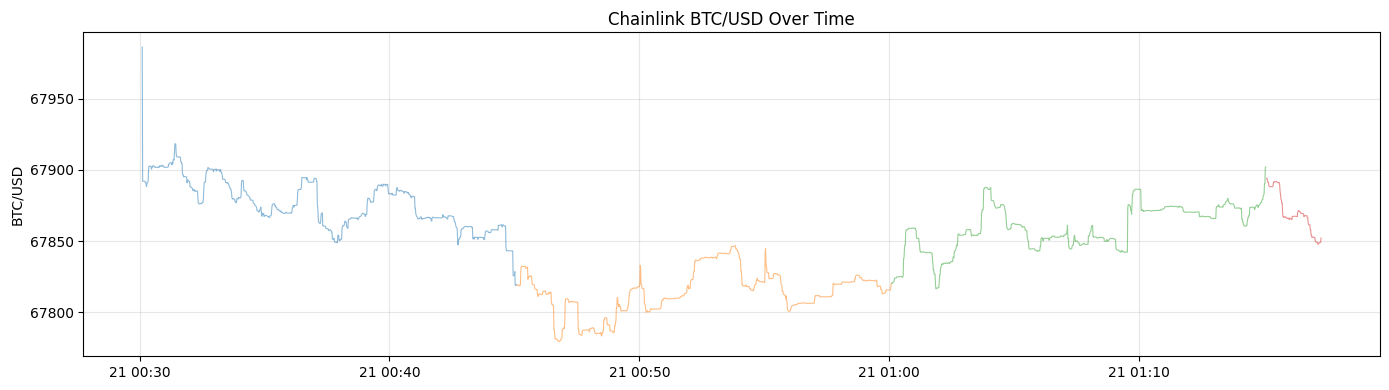

In [2]:
fig, ax = plt.subplots(figsize=(14, 4))
for slug in markets:
    m = df[df["market_slug"] == slug]
    ax.plot(m["ts"], m["chainlink_btc"], linewidth=0.8, alpha=0.5, label=slug)
ax.set_ylabel("BTC/USD")
ax.set_title("Chainlink BTC/USD Over Time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Best Bid / Ask (Up outcome)

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for slug in markets:
    m = df[df["market_slug"] == slug]
    ax1.plot(m["ts"], m["best_bid_up"], alpha=0.5, color="C0")
    ax1.plot(m["ts"], m["best_ask_up"], alpha=0.5, color="C1")
    ax1.fill_between(m["ts"], m["best_bid_up"], m["best_ask_up"], alpha=0.1)
ax1.set_ylabel("Price")
ax1.set_title("Up Outcome: Raw Bid / Ask")
ax1.grid(True, alpha=0.3)

for slug in markets:
    m = df[df["market_slug"] == slug]
    ax2.plot(m["ts"], m["eff_bid_up"], alpha=0.5, color="C0")
    ax2.plot(m["ts"], m["eff_ask_up"], alpha=0.5, color="C1")
    ax2.fill_between(m["ts"], m["eff_bid_up"], m["eff_ask_up"], alpha=0.1, color="C3")
ax2.set_ylabel("Price")
ax2.set_title("Up Outcome: Fee-Adjusted Bid / Ask (taker effective)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Mid Price & Spread

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for slug in markets:
    m = df[df["market_slug"] == slug]
    ax1.plot(m["ts"], m["eff_mid_up"], linewidth=0.8, alpha=0.5)
    ax1.plot(m["ts"], m["eff_mid_down"], linewidth=0.8, alpha=0.5)
ax1.set_ylabel("Mid Price")
ax1.set_title("Fee-Adjusted Mid Price (Up & Down per market)")
ax1.grid(True, alpha=0.3)

for slug in markets:
    m = df[df["market_slug"] == slug]
    ax2.plot(m["ts"], m["eff_spread_up"], linewidth=0.8, alpha=0.5)
    ax2.plot(m["ts"], m["eff_spread_down"], linewidth=0.8, alpha=0.5)
ax2.set_ylabel("Spread")
ax2.set_title("Fee-Adjusted Spread (Up & Down per market)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Book Imbalance (Top 5 Levels)

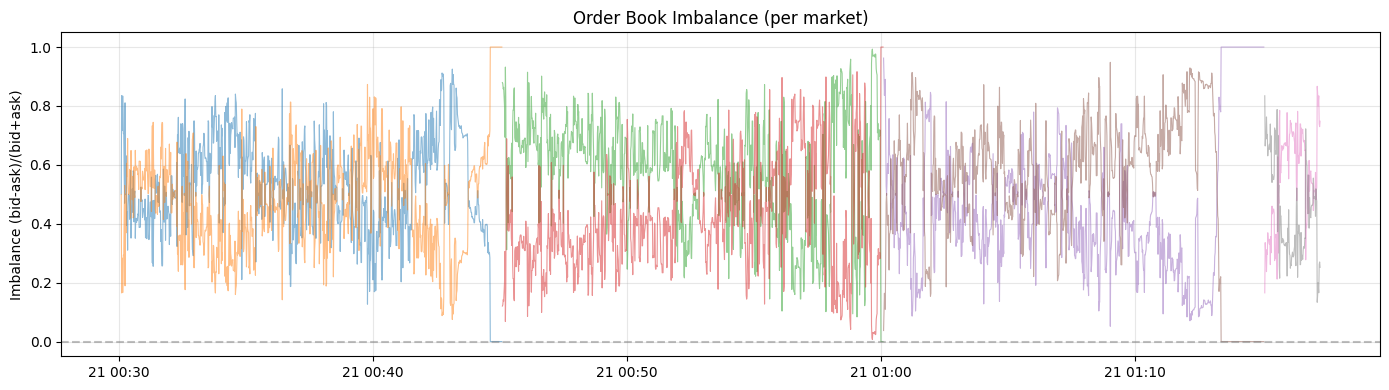

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
for slug in markets:
    m = df[df["market_slug"] == slug]
    ax.plot(m["ts"], m["imbalance5_up"], linewidth=0.8, alpha=0.5)
    ax.plot(m["ts"], m["imbalance5_down"], linewidth=0.8, alpha=0.5)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Imbalance (bid-ask)/(bid+ask)")
ax.set_title("Order Book Imbalance (per market)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Single Window Deep Dive

Window: btc-updown-15m-1771636500
Rows: 308  |  Duration: 894s


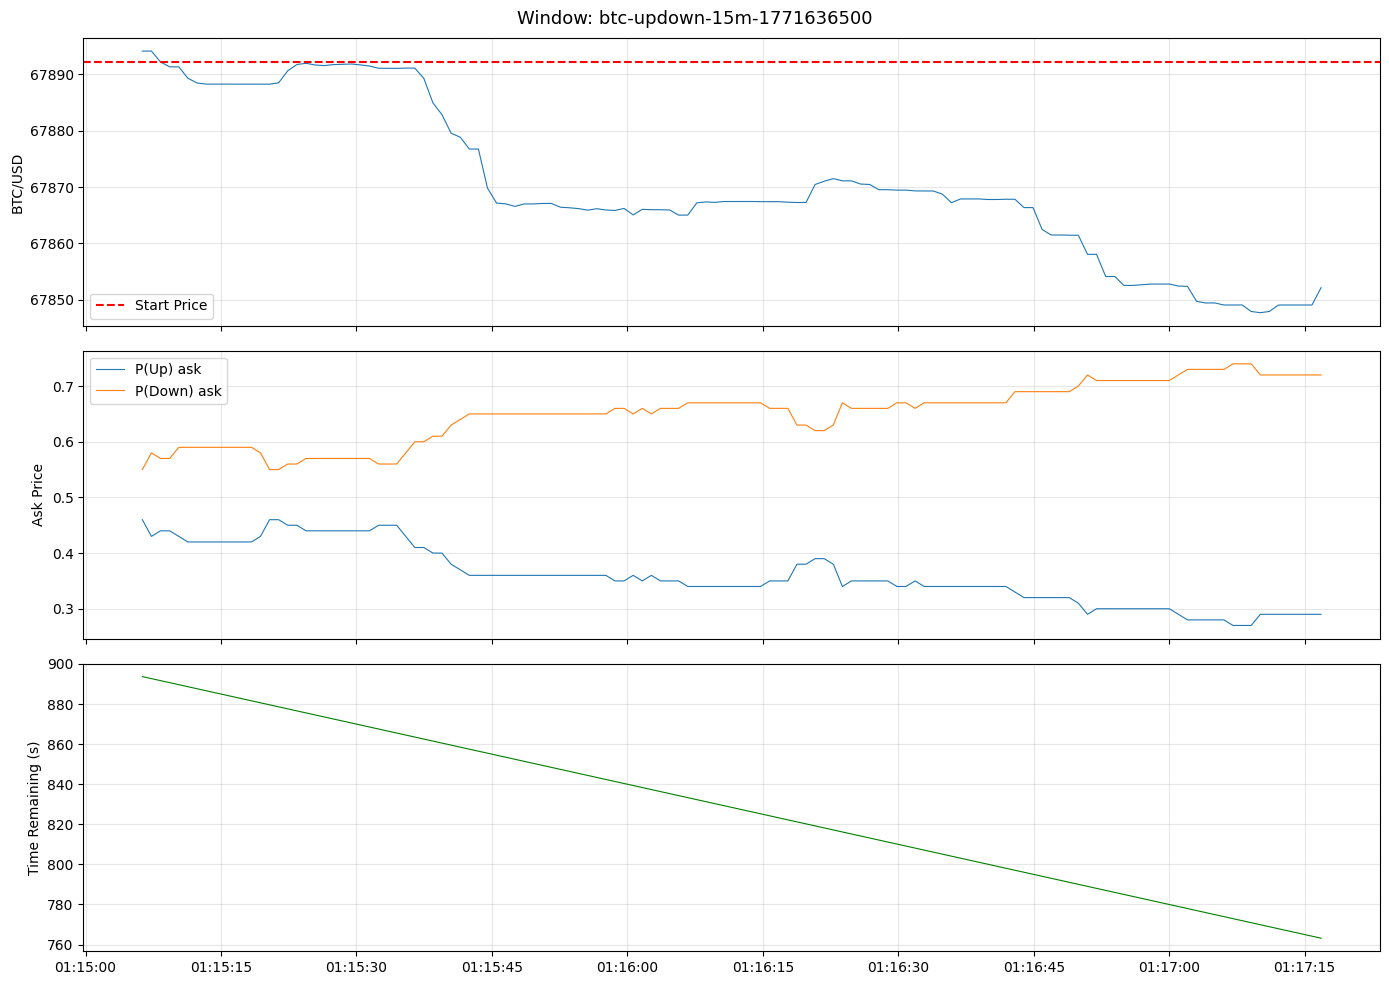

In [6]:
# Pick the latest window
latest = df[df["market_slug"] == df["market_slug"].iloc[-1]].copy()
print(f"Window: {latest['market_slug'].iloc[0]}")
print(f"Rows: {len(latest)}  |  Duration: {latest['time_remaining_s'].max():.0f}s")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(latest["ts"], latest["chainlink_btc"], linewidth=0.8)
if latest["window_start_price"].notna().any():
    axes[0].axhline(latest["window_start_price"].dropna().iloc[0], color="red", linestyle="--", label="Start Price")
axes[0].set_ylabel("BTC/USD")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(latest["ts"], latest["best_ask_up"], label="P(Up) ask", linewidth=0.8)
axes[1].plot(latest["ts"], latest["best_ask_down"], label="P(Down) ask", linewidth=0.8)
axes[1].set_ylabel("Ask Price")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(latest["ts"], latest["time_remaining_s"], linewidth=0.8, color="green")
axes[2].set_ylabel("Time Remaining (s)")
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Window: {latest['market_slug'].iloc[0]}", fontsize=13)
plt.tight_layout()
plt.show()

## Summary Stats

In [ ]:
df[["best_bid_up", "best_ask_up", "spread_up", "mid_up",
    "eff_bid_up", "eff_ask_up", "eff_spread_up", "eff_mid_up",
    "fee_ask_up", "fee_bid_up",
    "best_bid_down", "best_ask_down", "spread_down", "mid_down",
    "eff_bid_down", "eff_ask_down", "eff_spread_down", "eff_mid_down",
    "chainlink_btc"]].describe().round(4)